In [ ]:
# !pip uninstall -y torch torchvision torchaudio torch-higher-order-ops
# !pip install torch torchvision torchaudio

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from datasets import load_dataset
ds = load_dataset("Mireu-Lab/NSL-KDD")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/22.5M [00:00<?, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/151165 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/34394 [00:00<?, ? examples/s]

In [ ]:
#put dataset into pandas
df = ds['train'].to_pandas()

#label normal behavior 1 and anomolies 0
df['label'] = df['class'].apply(lambda x: 1 if x == "normal" else 0)


counts = df["label"].value_counts().sort_index()
percentages = df["label"].value_counts(normalize=True).sort_index() * 100

print("Counts:")
print(counts)
print("\nPercentages:")
print(percentages)

Counts:
label
0    70373
1    80792
Name: count, dtype: int64

Percentages:
label
0    46.553766
1    53.446234
Name: proportion, dtype: float64


In [ ]:
#split features and labels

X = df.drop(columns=["class", "label"])
y = df["label"]

#create split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)


print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.value_counts(normalize=True).sort_index() * 100)
print(y_val.value_counts(normalize=True).sort_index() * 100)
print(y_test.value_counts(normalize=True).sort_index() * 100)

(90699, 41) (30233, 41) (30233, 41)
label
0    46.553986
1    53.446014
Name: proportion, dtype: float64
label
0    46.551781
1    53.448219
Name: proportion, dtype: float64
label
0    46.555089
1    53.444911
Name: proportion, dtype: float64


In [ ]:
#defining categorical and continuous columns
categorical_cols = ["protocol_type", "service", "flag"]
continuous_cols = [col for col in X_train.columns if col not in categorical_cols]

print("Categorical:", categorical_cols)
print("Num categorical:", len(categorical_cols))
print("Num continuous:", len(continuous_cols))
print("First few continuous:", continuous_cols[:10])
# print("continuous_indices:", continuous_indices)

Categorical: ['protocol_type', 'service', 'flag']
Num categorical: 3
Num continuous: 38
First few continuous: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised']


In [ ]:
#one hot encode categorical and scale continuous

#One-hot encode categorical
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_val_cat = ohe.transform(X_val[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])

#Scale continuous
scaler = StandardScaler()

X_train_cont = scaler.fit_transform(X_train[continuous_cols])
X_val_cont = scaler.transform(X_val[continuous_cols])
X_test_cont = scaler.transform(X_test[continuous_cols])

#Combine them
X_train_processed = np.hstack([X_train_cont, X_train_cat])
X_val_processed = np.hstack([X_val_cont, X_val_cat])
X_test_processed = np.hstack([X_test_cont, X_test_cat])

#for FGSM use later * changed this position of codde block
continuous_indices = list(range(len(continuous_cols)))
categorical_indices = list(range(len(continuous_cols), X_train_processed.shape[1]))

print(X_train_processed.shape)
print(X_val_processed.shape)
print(X_test_processed.shape)

(90699, 120)
(30233, 120)
(30233, 120)


In [ ]:

#put ds into numpy
y_train_np = y_train.to_numpy().astype(np.float32)
y_val_np = y_val.to_numpy().astype(np.float32)
y_test_np = y_test.to_numpy().astype(np.float32)

#Features to numpy tensors
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

#Labels to numpy tensors
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)

#Datasets and loaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(X_train_tensor.shape, y_train_tensor.shape)
print(X_val_tensor.shape, y_val_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)

torch.Size([90699, 120]) torch.Size([90699, 1])
torch.Size([30233, 120]) torch.Size([30233, 1])
torch.Size([30233, 120]) torch.Size([30233, 1])


MLP CREATION


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

#Initialize model
input_dim = X_train_tensor.shape[1]
model = MLP(input_dim)

print(model)

MLP(
  (model): Sequential(
    (0): Linear(in_features=120, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:

#criterion for binary classification(input: raw model output; output: how wrong the prediction is)
criterion = nn.BCEWithLogitsLoss()
#updates weights using gradients... this is how our model learns
optimizer = optim.Adam(model.parameters(), lr=0.001)

#turns off training,
def evaluate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            outputs = model(X_batch)
            #convert logits to probability, threshold of .5

            preds = (torch.sigmoid(outputs) >= 0.5).float()
            #compute predictions
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)
 #compare to true labels
    return correct / total

num_epochs = 10

#training loop (one epoch is one full pass through training data)
for epoch in range(num_epochs):
    #enable gradient updates
    model.train()
    running_loss = 0.0
#uses batches of 64 instead of the whole dataset all at once(for performance)
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        #input to prediction... take current weights and produce logits
        outputs = model(X_batch)
        #compares prediction vs truth
        loss = criterion(outputs, y_batch)
        #which weights caused the errors and how much should each weight change
        loss.backward()
        #update weights to reduce future error
        optimizer.step()
        #track loss
        running_loss += loss.item()
    #after each epoch, measure how well the model performs
    train_acc = evaluate_accuracy(model, train_loader)
    val_acc = evaluate_accuracy(model, val_loader)


    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


Epoch [1/10] | Loss: 0.0603 | Train Acc: 0.9909 | Val Acc: 0.9896
Epoch [2/10] | Loss: 0.0220 | Train Acc: 0.9929 | Val Acc: 0.9917
Epoch [3/10] | Loss: 0.0191 | Train Acc: 0.9936 | Val Acc: 0.9927
Epoch [4/10] | Loss: 0.0164 | Train Acc: 0.9933 | Val Acc: 0.9924
Epoch [5/10] | Loss: 0.0150 | Train Acc: 0.9942 | Val Acc: 0.9933
Epoch [6/10] | Loss: 0.0141 | Train Acc: 0.9953 | Val Acc: 0.9945
Epoch [7/10] | Loss: 0.0130 | Train Acc: 0.9951 | Val Acc: 0.9938
Epoch [8/10] | Loss: 0.0126 | Train Acc: 0.9966 | Val Acc: 0.9957
Epoch [9/10] | Loss: 0.0117 | Train Acc: 0.9968 | Val Acc: 0.9955
Epoch [10/10] | Loss: 0.0113 | Train Acc: 0.9963 | Val Acc: 0.9950


breakdown:

network record
→ convert to numbers
→ feed into neural network
→ get prediction
→ compare with truth
→ adjust weights
→ repeat many times

Compute metrics:

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()

        all_preds.extend(preds.numpy())
        all_labels.extend(y_batch.numpy())
        all_probs.extend(probs.numpy())

#Convert to arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

#Metrics
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_probs)
pr_auc = average_precision_score(all_labels, all_probs)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")



#can use this when comparing baseline vs FGSM & baseline vs adversarial training
baseline_results = {
    "accuracy": evaluate_accuracy(model, test_loader),
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "roc_auc": roc_auc,
    "pr_auc": pr_auc
}

print('\n', baseline_results)

Precision: 0.9959
Recall: 0.9954
F1: 0.9956
ROC-AUC: 0.9998
PR-AUC: 0.9998

 {'accuracy': 0.9953031455694109, 'precision': 0.9958513931888545, 'recall': 0.9953583364277757, 'f1': 0.9956048037637737, 'roc_auc': np.float64(0.9998221580542235), 'pr_auc': np.float64(0.9998343985006272)}


FGSM attack

In [ ]:
# fgsm function to generate adversarial eg.
def fgsm_attack(model, X, y, continuous_indices, epsilon, categorical_indices, criterion):
    # returns adversarial eg. tensor
    X_adv = X.clone().detach().requires_grad_(True)

    outputs = model(X_adv)
    loss = criterion(outputs, y)

    loss.backward()

    grad_sign = X_adv.grad.sign()

    # Creating perturbation, only apply to continuous features
    perturbation = torch.zeros_like(X_adv)
    perturbation[:, continuous_indices] = epsilon * grad_sign[:, continuous_indices]

    # Applying perturbation
    X_adv = X.clone().detach() + perturbation

    # Clip continuous features to training min/max
    for i, idx in enumerate(continuous_indices):
        col_min = X_train_tensor[:, idx].min().item()
        col_max = X_train_tensor[:, idx].max().item()
        X_adv[:, idx] = torch.clamp(X_adv[:, idx], min=col_min, max=col_max)

    return X_adv.detach()

# Evaluating accuracy over adversarial examples

def evaluate_adversarial(model, X_adv, y):

    model.eval()
    with torch.no_grad():
        outputs = model(X_adv)
        preds = (torch.sigmoid(outputs) >= 0.5).float()
        correct = (preds == y).sum().item()
        total = y.size(0)
    return correct / total

# Run FGSM experiments over multiple epsilon values

epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3]

fgsm_results = []

print(f"{'Epsilon':<10} {'Clean Acc':<12} {'FGSM Acc':<12} {'Acc Drop':<10}")
print("-" * 44)

for eps in epsilons:
    # Generating adversarial test set
    X_adv = fgsm_attack(
        model=model,
        X=X_test_tensor,
        y=y_test_tensor,
        epsilon=eps,
        continuous_indices=continuous_indices,
        categorical_indices=categorical_indices,
        criterion=criterion
    )

    # Evaluate
    adv_acc = evaluate_adversarial(model, X_adv, y_test_tensor)
    clean_acc = baseline_results["accuracy"]
    drop = clean_acc - adv_acc

    fgsm_results.append({
        "epsilon": eps,
        "clean_accuracy": clean_acc,
        "fgsm_accuracy": adv_acc,
        "accuracy_drop": drop
    })

    print(f"{eps:<10.2f} {clean_acc:<12.4f} {adv_acc:<12.4f} {drop:<10.4f}")


Epsilon    Clean Acc    FGSM Acc     Acc Drop  
--------------------------------------------
0.00       0.9953       0.9953       0.0000    
0.01       0.9953       0.9943       0.0010    
0.05       0.9953       0.9883       0.0070    
0.10       0.9953       0.9678       0.0275    
0.20       0.9953       0.7928       0.2025    
0.30       0.9953       0.6514       0.3439    


In [ ]:
# Results table

fgsm_df = pd.DataFrame(fgsm_results)
print("\n", fgsm_df.to_string(index=False))


  epsilon  clean_accuracy  fgsm_accuracy  accuracy_drop
    0.00        0.995303       0.995303       0.000000
    0.01        0.995303       0.994344       0.000959
    0.05        0.995303       0.988258       0.007045
    0.10        0.995303       0.967817       0.027487
    0.20        0.995303       0.792776       0.202527
    0.30        0.995303       0.651374       0.343929


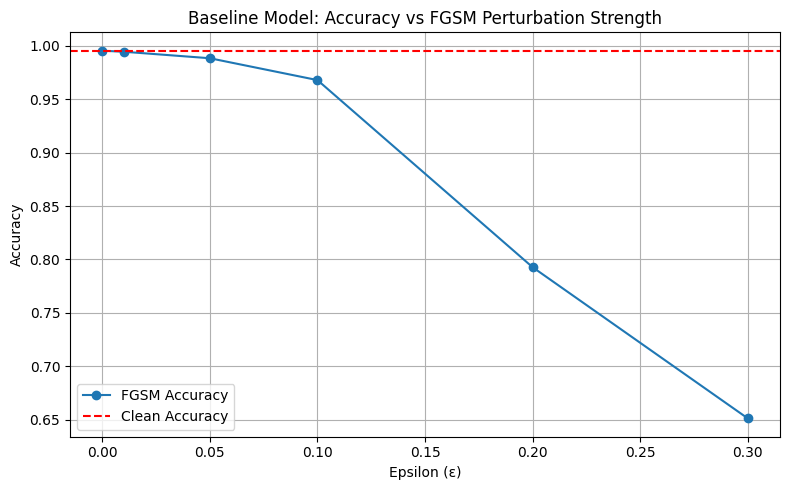

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(fgsm_df["epsilon"], fgsm_df["fgsm_accuracy"], marker='o', label="FGSM Accuracy")
plt.axhline(y=baseline_results["accuracy"], color='r', linestyle='--', label="Clean Accuracy")
plt.xlabel("Epsilon (ε)")
plt.ylabel("Accuracy")
plt.title("Baseline Model: Accuracy vs FGSM Perturbation Strength")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

PGD Attack - PGD = iterative FGSM with projection back into the epsilon-ball.

In [ ]:
# PGD Attack Function

def pgd_attack(model, X, y, epsilon, continuous_indices, categorical_indices, criterion,
               num_steps=10, step_size=None):

    # Returns: X_adv: adversarial examples tensor

    if step_size is None:
        step_size = epsilon / 4

    #Starts from a random point within the epsilon-ball (not from the clean input)
    #This helps PGD find stronger adversarial examples
    X_adv = X.clone().detach()
    random_noise = torch.zeros_like(X)
    random_noise[:, continuous_indices] = torch.empty(
        X.size(0), len(continuous_indices)
    ).uniform_(-epsilon, epsilon)
    X_adv = X_adv + random_noise

    # Storing the original for projection
    X_original = X.clone().detach()

    for step in range(num_steps):
        X_adv = X_adv.clone().detach().requires_grad_(True)

        outputs = model(X_adv)
        loss = criterion(outputs, y)

        loss.backward()

        # A small FGSM step
        grad_sign = X_adv.grad.sign()

        # Perturb continuous features
        perturbation = torch.zeros_like(X_adv)
        perturbation[:, continuous_indices] = step_size * grad_sign[:, continuous_indices]

        X_adv = X_adv.detach() + perturbation

        delta = X_adv - X_original
        delta[:, continuous_indices] = torch.clamp(
            delta[:, continuous_indices], min=-epsilon, max=epsilon
        )
        X_adv = X_original + delta

        for idx in continuous_indices:
            col_min = X_train_tensor[:, idx].min().item()
            col_max = X_train_tensor[:, idx].max().item()
            X_adv[:, idx] = torch.clamp(X_adv[:, idx], min=col_min, max=col_max)

        # Ensuring categorical features are never modified
        X_adv[:, categorical_indices] = X_original[:, categorical_indices]

    return X_adv.detach()

epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3]

pgd_results = []

print(f"{'Epsilon':<10} {'Clean Acc':<12} {'PGD Acc':<12} {'Acc Drop':<10}")
print("-" * 44)

for eps in epsilons:
    X_adv = pgd_attack(
        model=model,
        X=X_test_tensor,
        y=y_test_tensor,
        epsilon=eps,
        continuous_indices=continuous_indices,
        categorical_indices=categorical_indices,
        criterion=criterion,
        num_steps=10,
        step_size=eps / 4
    )

    adv_acc = evaluate_adversarial(model, X_adv, y_test_tensor)
    clean_acc = baseline_results["accuracy"]
    drop = clean_acc - adv_acc

    pgd_results.append({
        "epsilon": eps,
        "clean_accuracy": clean_acc,
        "pgd_accuracy": adv_acc,
        "accuracy_drop": drop
    })

    print(f"{eps:<10.2f} {clean_acc:<12.4f} {adv_acc:<12.4f} {drop:<10.4f}")

Epsilon    Clean Acc    PGD Acc      Acc Drop  
--------------------------------------------
0.00       0.9953       0.9953       0.0000    
0.01       0.9953       0.9943       0.0010    
0.05       0.9953       0.9878       0.0075    
0.10       0.9953       0.9648       0.0305    
0.20       0.9953       0.7602       0.2351    
0.30       0.9953       0.5644       0.4309    


In [ ]:
pgd_df = pd.DataFrame(pgd_results)
print("\n", pgd_df.to_string(index=False))


  epsilon  clean_accuracy  pgd_accuracy  accuracy_drop
    0.00        0.995303      0.995303       0.000000
    0.01        0.995303      0.994344       0.000959
    0.05        0.995303      0.987828       0.007475
    0.10        0.995303      0.964807       0.030496
    0.20        0.995303      0.760229       0.235074
    0.30        0.995303      0.564383       0.430920


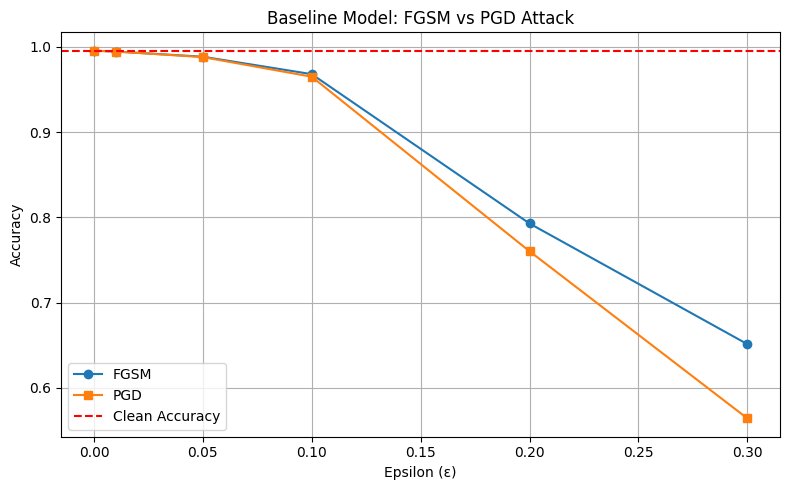

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(fgsm_df["epsilon"], fgsm_df["fgsm_accuracy"], marker='o', label="FGSM")
plt.plot(pgd_df["epsilon"], pgd_df["pgd_accuracy"], marker='s', label="PGD")
plt.axhline(y=baseline_results["accuracy"], color='r', linestyle='--', label="Clean Accuracy")
plt.xlabel("Epsilon (ε)")
plt.ylabel("Accuracy")
plt.title("Baseline Model: FGSM vs PGD Attack")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Adversarial Training

In [ ]:
#Adversarial Training

# Create a fresh MLP with the same architecture
adv_model = MLP(input_dim)
adv_criterion = nn.BCEWithLogitsLoss()
adv_optimizer = optim.Adam(adv_model.parameters(), lr=0.001)

# Epsilon used to generate adversarial examples during training
adv_train_epsilon = 0.1

num_epochs = 10

for epoch in range(num_epochs):
    adv_model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Generate FGSM adversarial examples for this batch
        X_batch_adv = X_batch.clone().detach().requires_grad_(True)
        outputs_adv = adv_model(X_batch_adv)
        loss_adv = adv_criterion(outputs_adv, y_batch)
        loss_adv.backward()

        grad_sign = X_batch_adv.grad.sign()

        perturbation = torch.zeros_like(X_batch_adv)
        perturbation[:, continuous_indices] = adv_train_epsilon * grad_sign[:, continuous_indices]

        X_batch_adv = X_batch.clone().detach() + perturbation

        # Clipping to valid range
        for idx in continuous_indices:
            col_min = X_train_tensor[:, idx].min().item()
            col_max = X_train_tensor[:, idx].max().item()
            X_batch_adv[:, idx] = torch.clamp(X_batch_adv[:, idx], min=col_min, max=col_max)

        X_batch_adv = X_batch_adv.detach()

        #Combining clean and adversarial into one batch
        X_combined = torch.cat([X_batch, X_batch_adv], dim=0)
        y_combined = torch.cat([y_batch, y_batch], dim=0)

        # Training on the combined batch
        adv_optimizer.zero_grad()
        outputs = adv_model(X_combined)
        loss = adv_criterion(outputs, y_combined)
        loss.backward()
        adv_optimizer.step()

        running_loss += loss.item()

    # performance each epoch
    train_acc = evaluate_accuracy(adv_model, train_loader)
    val_acc = evaluate_accuracy(adv_model, val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {running_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")


#Evaluating adversarially trained model - clean accuracy

adv_clean_acc = evaluate_accuracy(adv_model, test_loader)
print(f"\nAdv-trained model clean accuracy: {adv_clean_acc:.4f}")
print(f"Baseline model clean accuracy:    {baseline_results['accuracy']:.4f}")


# Evaluate both models under FGSM and PGD across epsilons

epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.3]

comparison_results = []

print(f"\n{'Eps':<6} {'Base FGSM':<11} {'Adv FGSM':<11} {'Base PGD':<11} {'Adv PGD':<11}")
print("-" * 50)

for eps in epsilons:
    # FGSM on baseline
    X_fgsm_base = fgsm_attack(model, X_test_tensor, y_test_tensor,
                           continuous_indices, eps, categorical_indices, criterion)
    acc_fgsm_base = evaluate_adversarial(model, X_fgsm_base, y_test_tensor)

    # FGSM on adv-trained
    X_fgsm_adv = fgsm_attack(adv_model, X_test_tensor, y_test_tensor,
                              continuous_indices, eps, categorical_indices, adv_criterion)
    acc_fgsm_adv = evaluate_adversarial(adv_model, X_fgsm_adv, y_test_tensor)

    # PGD on baseline
    X_pgd_base = pgd_attack(model, X_test_tensor, y_test_tensor, eps,
                             continuous_indices, categorical_indices, criterion)
    acc_pgd_base = evaluate_adversarial(model, X_pgd_base, y_test_tensor)

    # PGD on adv-trained
    X_pgd_adv = pgd_attack(adv_model, X_test_tensor, y_test_tensor, eps,
                            continuous_indices, categorical_indices, adv_criterion)
    acc_pgd_adv = evaluate_adversarial(adv_model, X_pgd_adv, y_test_tensor)

    comparison_results.append({
        "epsilon": eps,
        "baseline_fgsm": acc_fgsm_base,
        "advtrained_fgsm": acc_fgsm_adv,
        "baseline_pgd": acc_pgd_base,
        "advtrained_pgd": acc_pgd_adv
    })

    print(f"{eps:<6.2f} {acc_fgsm_base:<11.4f} {acc_fgsm_adv:<11.4f} {acc_pgd_base:<11.4f} {acc_pgd_adv:<11.4f}")

comp_df = pd.DataFrame(comparison_results)

Epoch [1/10] | Loss: 0.0771 | Train Acc: 0.9916 | Val Acc: 0.9908
Epoch [2/10] | Loss: 0.0329 | Train Acc: 0.9934 | Val Acc: 0.9927
Epoch [3/10] | Loss: 0.0271 | Train Acc: 0.9942 | Val Acc: 0.9936
Epoch [4/10] | Loss: 0.0241 | Train Acc: 0.9945 | Val Acc: 0.9937
Epoch [5/10] | Loss: 0.0223 | Train Acc: 0.9943 | Val Acc: 0.9935
Epoch [6/10] | Loss: 0.0209 | Train Acc: 0.9948 | Val Acc: 0.9937
Epoch [7/10] | Loss: 0.0199 | Train Acc: 0.9951 | Val Acc: 0.9943
Epoch [8/10] | Loss: 0.0186 | Train Acc: 0.9948 | Val Acc: 0.9937
Epoch [9/10] | Loss: 0.0181 | Train Acc: 0.9955 | Val Acc: 0.9946
Epoch [10/10] | Loss: 0.0171 | Train Acc: 0.9962 | Val Acc: 0.9951

Adv-trained model clean accuracy: 0.9956
Baseline model clean accuracy:    0.9953

Eps    Base FGSM   Adv FGSM    Base PGD    Adv PGD    
--------------------------------------------------
0.00   0.9953      0.9956      0.9953      0.9956     
0.01   0.9943      0.9955      0.9943      0.9955     
0.05   0.9883      0.9948      0.9878  

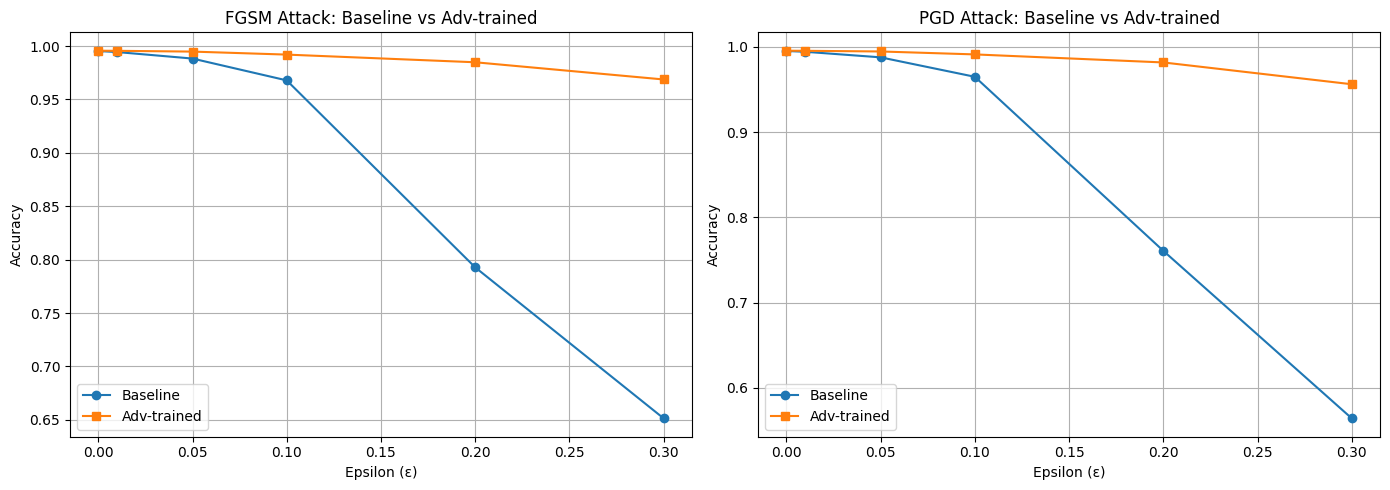

In [ ]:
# Final comparison plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FGSM comparison
axes[0].plot(comp_df["epsilon"], comp_df["baseline_fgsm"], marker='o', label="Baseline")
axes[0].plot(comp_df["epsilon"], comp_df["advtrained_fgsm"], marker='s', label="Adv-trained")
axes[0].set_xlabel("Epsilon (ε)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("FGSM Attack: Baseline vs Adv-trained")
axes[0].legend()
axes[0].grid(True)

# PGD comparison
axes[1].plot(comp_df["epsilon"], comp_df["baseline_pgd"], marker='o', label="Baseline")
axes[1].plot(comp_df["epsilon"], comp_df["advtrained_pgd"], marker='s', label="Adv-trained")
axes[1].set_xlabel("Epsilon (ε)")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("PGD Attack: Baseline vs Adv-trained")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Comparision table

In [ ]:
# comparison table
print("\nFull comparison table:")
print(comp_df.to_string(index=False))

# formatted for the report
print("\n\nFormatted summary:\n")
print(f"{'Eps':<8} {'Base FGSM':<14} {'Adv FGSM':<14} {'Base PGD':<14} {'Adv PGD':<14}")
print("-" * 64)
for _, row in comp_df.iterrows():
    print(f"{row['epsilon']:<8.2f} {row['baseline_fgsm']:<14.4f} {row['advtrained_fgsm']:<14.4f} {row['baseline_pgd']:<14.4f} {row['advtrained_pgd']:<14.4f}")

# how much did adversarial training actually help?
print("\n\nRobustness gain (adv-trained minus baseline):\n")
for _, row in comp_df.iterrows():
    fgsm_gain = row['advtrained_fgsm'] - row['baseline_fgsm']
    pgd_gain = row['advtrained_pgd'] - row['baseline_pgd']
    print(f"eps={row['epsilon']:.2f}  FGSM: {fgsm_gain:+.4f}  PGD: {pgd_gain:+.4f}")


Full comparison table:
 epsilon  baseline_fgsm  advtrained_fgsm  baseline_pgd  advtrained_pgd
    0.00       0.995303         0.995601      0.995303        0.995601
    0.01       0.994344         0.995502      0.994344        0.995502
    0.05       0.988258         0.994774      0.987828        0.994708
    0.10       0.967817         0.991962      0.965005        0.991268
    0.20       0.792776         0.984785      0.760890        0.981841
    0.30       0.651374         0.968677      0.564383        0.956273


Formatted summary:

Eps      Base FGSM      Adv FGSM       Base PGD       Adv PGD       
----------------------------------------------------------------
0.00     0.9953         0.9956         0.9953         0.9956        
0.01     0.9943         0.9955         0.9943         0.9955        
0.05     0.9883         0.9948         0.9878         0.9947        
0.10     0.9678         0.9920         0.9650         0.9913        
0.20     0.7928         0.9848         0.7609  